# Лабораторная работа № 2 ТМО

# Кудабаева Эвита ИУ5-62Б


## Источник данных: Встроенный датасет библиотеки `Seaborn` (`Titanic`).

## Предметная область: Морской транспорт.

Описание:
Набор данных "Титаник"  — это классический набор данных для задач классификации и визуализации. 
Описание датасета:
- Пассажиры Titanic (891 запись)
- Содержит информацию о пассажирах: класс, имя, пол, возраст, тариф, порт посадки и выживаемость
- Преимущества для лабораторной работы:
  - Есть пропуски (Age, Cabin, Embarked)
  - Есть категориальные признаки (Sex, Embarked)
  - Есть числовые признаки для масштабирования (Age, Fare)
  - Небольшой размер, удобный для обработки

In [ ]:

# 1. импортируем датасет и библиотеки
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)
sns.set_style("whitegrid")


df = sns.load_dataset('titanic')

print("Датасет Titanic загружен!")
print(f"Размер датасета: {df.shape[0]} строк, {df.shape[1]} столбцов")


print("\nПервые 5 строк датасета:")
df.head()

Датасет Titanic загружен!
Размер датасета: 891 строк, 15 столбцов

Первые 5 строк датасета:


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [15]:
# 2. первичный анализ
print("="*60)
print("2.1 Информация о датасете")
print("="*60)
df.info()

print("\n" + "="*60)
print("2.2 Характеристика признаков")
print("="*60)
df.describe()

print("\n" + "="*60)
print("2.3 Статистика категорий")
print("="*60)
df.describe(include=['object', 'category'])

print("\n" + "="*60)
print("2.4 Типы данных")
print("="*60)
print(df.dtypes)

2.1 Информация о датасете
<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    str     
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    str     
 8   class        891 non-null    category
 9   who          891 non-null    str     
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    str     
 13  alive        891 non-null    str     
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), str(5)
memory usage: 80.7 KB

2.2 Характеристика признаков

2.3 Статистика категорий

2.4 Типы да

C:\Users\cabel\AppData\Local\Temp\ipykernel_9632\900234334.py:15: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df.describe(include=['object', 'category'])


3.1 Кол-во пропусков по столбцу
             Пропусков  Процент
deck               688    77.22
age                177    19.87
embarked             2     0.22
embark_town          2     0.22


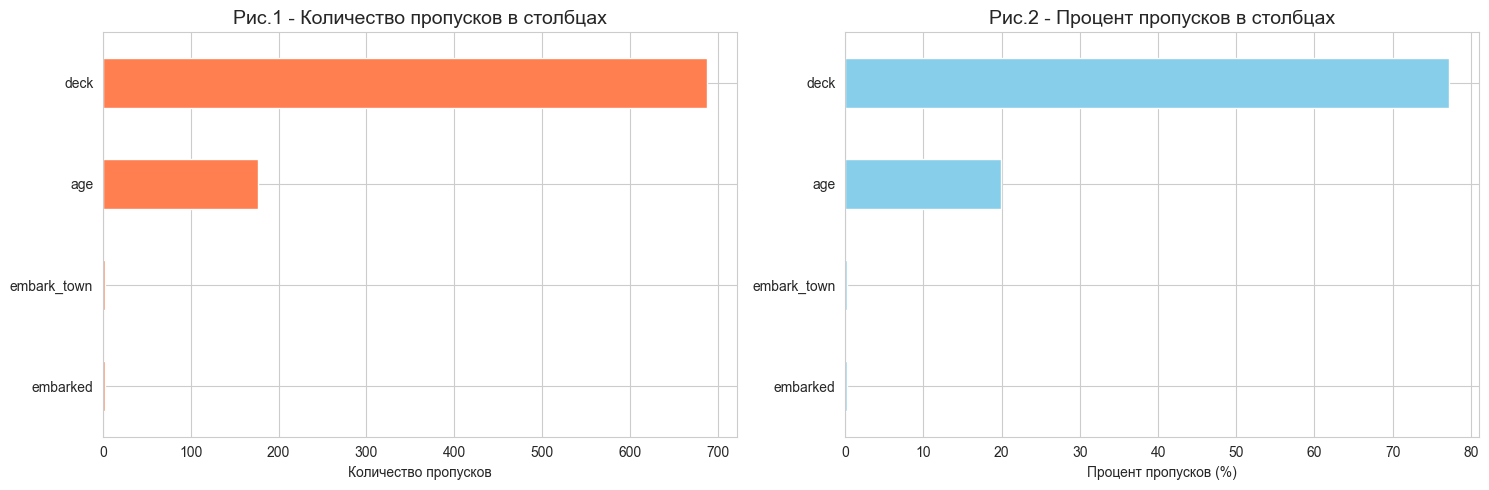


Выводы:
- age: пропущено 177 значений (19.87%) 
- embarked: пропущено 2 значения (0.22%) 
- deck: пропущено 688 значений (77.22%) 
- embark_town: пропущено 2 значения (0.22%) 



In [ ]:
# 3. Анализируем исходную структуру
print("="*60)
print("3.1 Кол-во пропусков по столбцу")
print("="*60)
missing_data = df.isnull().sum()
missing_percent = (missing_data / len(df)) * 100

missing_df = pd.DataFrame({
    'Пропусков': missing_data,
    'Процент': missing_percent.round(2)
})
missing_df = missing_df[missing_df['Пропусков'] > 0].sort_values('Пропусков', ascending=False)
print(missing_df)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))


missing_data[missing_data > 0].sort_values().plot(kind='barh', ax=axes[0], color='coral')
axes[0].set_title('Рис.1 - Количество пропусков в столбцах', fontsize=14)
axes[0].set_xlabel('Количество пропусков')

missing_percent[missing_percent > 0].sort_values().plot(kind='barh', ax=axes[1], color='skyblue')
axes[1].set_title('Рис.2 - Процент пропусков в столбцах', fontsize=14)
axes[1].set_xlabel('Процент пропусков (%)')

plt.tight_layout()
plt.show()


# plt.figure(figsize=(12, 8))
# sns.heatmap(df.isnull(), cbar=False, cmap='viridis', yticklabels=False)
# plt.title('Рис.3 - Тепловая карта пропусков (желтое = пропуск)', fontsize=16)
# plt.xlabel('Столбцы')
# plt.ylabel('Строки')
# plt.tight_layout()
# plt.show()

print("""
Выводы:
- age: пропущено 177 значений (19.87%) 
- embarked: пропущено 2 значения (0.22%) 
- deck: пропущено 688 значений (77.22%) 
- embark_town: пропущено 2 значения (0.22%) 
""")

4.1 Пропуски в 'age'


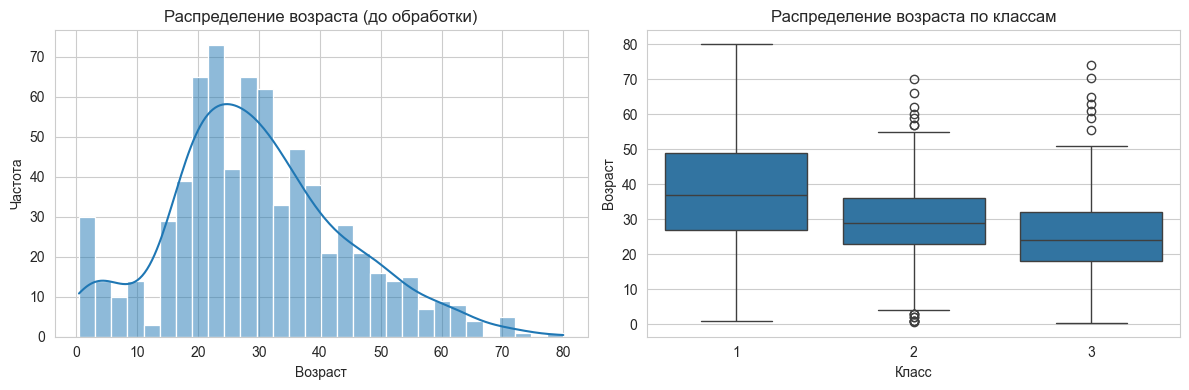

Заполняем пропуски в возрасте медианой по классу...
Медианы возраста по классам:
pclass
1    37.0
2    29.0
3    24.0
Name: age, dtype: float64

Осталось пропусков в age: 0

4.2 Пропуски в 'embarked'
Распределение портов посадки:
embarked
S      644
C      168
Q       77
NaN      2
Name: count, dtype: int64

Заполнили пропуски модой: 'S'
Осталось пропусков в embarked: 2

4.3 Пропуски в 'deck'
Процент пропусков в deck: 77.2%
Удаляем столбец 'deck', так как пропусков > 75%

4.4 Пропуски в 'embark_town'
Удаляем столбец 'embark_town' (дублирует 'embarked')

4.5 После обработки пропусков
Оставшиеся пропуски:
embarked    2
dtype: int64


C:\Users\cabel\AppData\Local\Temp\ipykernel_9632\2141797104.py:53: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  df_clean['embarked'].fillna(mode_embarked, inplace=True)


In [ ]:
# 4. Обработка пропусков

df_clean = df.copy()

print("="*60)
print("4.1 Пропуски в 'age'")
print("="*60)


plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
sns.histplot(df_clean['age'].dropna(), bins=30, kde=True)
plt.title('Распределение возраста (до обработки)')
plt.xlabel('Возраст')
plt.ylabel('Частота')

plt.subplot(1, 2, 2)
sns.boxplot(data=df_clean, x='pclass', y='age')
plt.title('Распределение возраста по классам')
plt.xlabel('Класс')
plt.ylabel('Возраст')

plt.tight_layout()
plt.show()


print("Заполняем пропуски в возрасте медианой по классу...")
age_medians = df_clean.groupby('pclass')['age'].median()
print(f"Медианы возраста по классам:\n{age_medians}")  


def fill_age(row):
    if pd.isnull(row['age']):
        return age_medians[row['pclass']]
    else:
        return row['age']

df_clean['age'] = df_clean.apply(fill_age, axis=1)

print(f"\nОсталось пропусков в age: {df_clean['age'].isnull().sum()}")

print("\n" + "="*60)
print("4.2 Пропуски в 'embarked'")
print("="*60)


print("Распределение портов посадки:")
print(df_clean['embarked'].value_counts(dropna=False))


mode_embarked = df_clean['embarked'].mode()[0]
df_clean['embarked'].fillna(mode_embarked, inplace=True)
print(f"\nЗаполнили пропуски модой: '{mode_embarked}'")
print(f"Осталось пропусков в embarked: {df_clean['embarked'].isnull().sum()}")

print("\n" + "="*60)
print("4.3 Пропуски в 'deck'")
print("="*60)

print(f"Процент пропусков в deck: {df_clean['deck'].isnull().mean()*100:.1f}%")
print("Удаляем столбец 'deck', так как пропусков > 75%")
df_clean.drop('deck', axis=1, inplace=True)

print("\n" + "="*60)
print("4.4 Пропуски в 'embark_town'")
print("="*60)


print("Удаляем столбец 'embark_town' (дублирует 'embarked')")
df_clean.drop('embark_town', axis=1, inplace=True)

print("\n" + "="*60)
print("4.5 После обработки пропусков")
print("="*60)
print("Оставшиеся пропуски:")
print(df_clean.isnull().sum()[df_clean.isnull().sum() > 0])

In [ ]:
# 5. Категориальные данные
print("="*60)
print("5.1 Выделение категориальных признаков (КП) ")
print("="*60)

categorical_cols = df_clean.select_dtypes(include=['object', 'category']).columns.tolist()
print(f"Категориальные признаки (object/category): {categorical_cols}")


bool_cols = df_clean.select_dtypes(include=['bool']).columns.tolist()
print(f"Булевы признаки: {bool_cols}")


all_categorical = categorical_cols + bool_cols
print(f"\nВсего категориальных признаков: {len(all_categorical)}")

print("\n" + "="*60)
print("5.2 Уникальные в КП")
print("="*60)

for col in all_categorical:
    print(f"\n{col}:")
    print(f"  Уникальных значений: {df_clean[col].nunique()}")
    print(f"  Значения: {df_clean[col].unique()[:10]}") 
    if df_clean[col].dtype == 'bool':
        print(f"  Тип: булевый (подходит для Label Encoding)")
    elif df_clean[col].nunique() == 2:
        print(f"  Тип: бинарный (подходит для Label Encoding)")
    else:
        print(f"  Тип: мульти-категориальный (нужен One-Hot Encoding)")

5.1 Выделение категориальных признаков (КП) 
Категориальные признаки (object/category): ['sex', 'embarked', 'class', 'who', 'alive']
Булевы признаки: ['adult_male', 'alone']

Всего категориальных признаков: 7

5.2 Уникальные в КП

sex:
  Уникальных значений: 2
  Значения: <StringArray>
['male', 'female']
Length: 2, dtype: str
  Тип: бинарный (подходит для Label Encoding)

embarked:
  Уникальных значений: 3
  Значения: <StringArray>
['S', 'C', 'Q', nan]
Length: 4, dtype: str
  Тип: мульти-категориальный (нужен One-Hot Encoding)

class:
  Уникальных значений: 3
  Значения: ['Third', 'First', 'Second']
Categories (3, str): ['First', 'Second', 'Third']
  Тип: мульти-категориальный (нужен One-Hot Encoding)

who:
  Уникальных значений: 3
  Значения: <StringArray>
['man', 'woman', 'child']
Length: 3, dtype: str
  Тип: мульти-категориальный (нужен One-Hot Encoding)

alive:
  Уникальных значений: 2
  Значения: <StringArray>
['no', 'yes']
Length: 2, dtype: str
  Тип: бинарный (подходит для Label

C:\Users\cabel\AppData\Local\Temp\ipykernel_9632\413432277.py:7: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = df_clean.select_dtypes(include=['object', 'category']).columns.tolist()


In [ ]:

# 6. Кодирование КП

from sklearn.preprocessing import LabelEncoder


df_encoded = df_clean.copy()

print("="*60)
print("6.1 Для бинарных признаков")
print("="*60)
print("Label Encoding подходит для признаков с 2 уникальными значениями")

le_sex = LabelEncoder()
df_encoded['sex_encoded'] = le_sex.fit_transform(df_encoded['sex'])
print("\n1. Пол (sex):")
print(f"   Было: {df_encoded['sex'].unique()}")
print(f"   Стало: {df_encoded['sex_encoded'].unique()}")
print(f"   Соответствие: {dict(zip(le_sex.classes_, le_sex.transform(le_sex.classes_)))}")


le_alone = LabelEncoder()
df_encoded['alone_encoded'] = le_alone.fit_transform(df_encoded['alone'])
print("\n2. Одиночка (alone):")
print(f"   Было: {df_encoded['alone'].unique()}")
print(f"   Стало: {df_encoded['alone_encoded'].unique()}")
print(f"   Соответствие: {dict(zip(le_alone.classes_, le_alone.transform(le_alone.classes_)))}")


le_adult = LabelEncoder()
df_encoded['adult_male_encoded'] = le_adult.fit_transform(df_encoded['adult_male'])
print("\n3. Взрослый мужчина (adult_male):")
print(f"   Было: {df_encoded['adult_male'].unique()}")
print(f"   Стало: {df_encoded['adult_male_encoded'].unique()}")
print(f"   Соответствие: {dict(zip(le_adult.classes_, le_adult.transform(le_adult.classes_)))}")


le_who = LabelEncoder()
df_encoded['who_encoded'] = le_who.fit_transform(df_encoded['who'])
print("\n4. Категория who (Пример Label Encoding):")
print(f"   Было: {df_encoded['who'].unique()}")
print(f"   Стало: {df_encoded['who_encoded'].unique()}")
print(f"   Соответствие: {dict(zip(le_who.classes_, le_who.transform(le_who.classes_)))}")
print("   !!! Label Encoding создает порядок (0<1<2), хотя 'man' не больше 'child'!")
print("   Для who лучше использовать One-Hot Encoding")

print("\n" + "="*60)
print("6.2 One-hot для нормальных признаков ")
print("="*60)
print("One-Hot Encoding для признаков без естественного порядка")


embarked_dummies = pd.get_dummies(df_encoded['embarked'], prefix='embarked', drop_first=False)
df_encoded = pd.concat([df_encoded, embarked_dummies], axis=1)
print("\n1. Порт посадки (embarked):")
print(f"   Было: {df_encoded['embarked'].unique()}")
print(f"   Создано {embarked_dummies.shape[1]} новых признаков: {list(embarked_dummies.columns)}")
print(f"   Пример для первой строки:")
print(f"     Было: {df_encoded['embarked'].iloc[0]}")
print(f"     Стало: {df_encoded[embarked_dummies.columns].iloc[0].to_dict()}")

who_dummies = pd.get_dummies(df_encoded['who'], prefix='who', drop_first=False)
df_encoded = pd.concat([df_encoded, who_dummies], axis=1)
print("\n2. Категория who:")
print(f"   Было: {df_encoded['who'].unique()}")
print(f"   Создано {who_dummies.shape[1]} новых признаков: {list(who_dummies.columns)}")


pclass_dummies = pd.get_dummies(df_encoded['pclass'], prefix='class', drop_first=False)
df_encoded = pd.concat([df_encoded, pclass_dummies], axis=1)
print("\n3. Класс (pclass):")
print(f"   Было: {df_encoded['pclass'].unique()}")
print(f"   Создано {pclass_dummies.shape[1]} новых признаков: {list(pclass_dummies.columns)}")

print("\n" + "="*60)
print("6.3 Сравнение")
print("="*60)

print("""
Label Encoding vs One-Hot Encoding:

1. Label Encoding:
   - Экономит память (1 столбец вместо многих)
   - Хорош для бинарных признаков
   - Создает ложный порядок (если признак не упорядочен)
   
2. One-Hot Encoding:
   - Не создает ложных зависимостей
   - Подходит для любых категорий
   - Требует много памяти (много столбцов)
""")

print(f"\nРазмер до кодирования: {df_clean.shape}")
print(f"Размер после кодирования: {df_encoded.shape}")
print(f"Добавлено признаков: {df_encoded.shape[1] - df_clean.shape[1]}")


new_cols = set(df_encoded.columns) - set(df_clean.columns)
print(f"\nНовые колонки после кодирования ({len(new_cols)}):")
print(sorted(list(new_cols))[:10]) 

6.1 Для бинарных признаков
Label Encoding подходит для признаков с 2 уникальными значениями

1. Пол (sex):
   Было: <StringArray>
['male', 'female']
Length: 2, dtype: str
   Стало: [1 0]
   Соответствие: {'female': np.int64(0), 'male': np.int64(1)}

2. Одиночка (alone):
   Было: [False  True]
   Стало: [0 1]
   Соответствие: {np.False_: np.int64(0), np.True_: np.int64(1)}

3. Взрослый мужчина (adult_male):
   Было: [ True False]
   Стало: [1 0]
   Соответствие: {np.False_: np.int64(0), np.True_: np.int64(1)}

4. Категория who (Пример Label Encoding):
   Было: <StringArray>
['man', 'woman', 'child']
Length: 3, dtype: str
   Стало: [1 2 0]
   Соответствие: {'child': np.int64(0), 'man': np.int64(1), 'woman': np.int64(2)}
   !!! Label Encoding создает порядок (0<1<2), хотя 'man' не больше 'child'!
   Для who лучше использовать One-Hot Encoding

6.2 One-hot для нормальных признаков 
One-Hot Encoding для признаков без естественного порядка

1. Порт посадки (embarked):
   Было: <StringArray>


In [ ]:

# 7. Проверка результатов кодирования

print("="*60)
print("7.1 Бинарные после LE")
print("="*60)


print("Сравнение исходных и закодированных бинарных признаков:")
print("\nПол (sex):")
print(pd.crosstab(df_encoded['sex'], df_encoded['sex_encoded'], margins=True))

print("\nОдиночка (alone):")
print(pd.crosstab(df_encoded['alone'], df_encoded['alone_encoded'], margins=True))

print("\n" + "="*60)
print("7.2 One-Hot ")
print("="*60)


print("Порт посадки (embarked) и One-Hot столбцы:")
embarked_cols = [col for col in df_encoded.columns if col.startswith('embarked_')]
print(df_encoded[['embarked'] + embarked_cols].head(10))

print("\n" + "="*60)
print("7.3 !!! Дубликаты")
print("="*60)

print("""
!!!
- Мы сохранили исходные категориальные признаки (sex, embarked, who и др.)
- И добавили новые закодированные версии
- При построении моделей нужно использовать только закодированные признаки,
  либо удалить исходные, чтобы избежать дублирования информации
""")

7.1 Бинарные после LE
Сравнение исходных и закодированных бинарных признаков:

Пол (sex):
sex_encoded    0    1  All
sex                       
female       314    0  314
male           0  577  577
All          314  577  891

Одиночка (alone):
alone_encoded    0    1  All
alone                       
False          354    0  354
True             0  537  537
All            354  537  891

7.2 One-Hot 
Порт посадки (embarked) и One-Hot столбцы:
  embarked  embarked_C  embarked_Q  embarked_S
0        S       False       False        True
1        C        True       False       False
2        S       False       False        True
3        S       False       False        True
4        S       False       False        True
5        Q       False        True       False
6        S       False       False        True
7        S       False       False        True
8        S       False       False        True
9        C        True       False       False

7.3 !!! Дубликаты

!!!
- Мы сохранил

In [ ]:
# 8. Для масштаба
print("="*60)
print("8.1 Выделение числовых п для масштабирования")
print("="*60)


numerical_cols = df_encoded.select_dtypes(include=['int64', 'float64']).columns.tolist()
print(f"Все числовые признаки ({len(numerical_cols)}):")
print(numerical_cols)

binary_cols = []
continuous_cols = []

for col in numerical_cols:
    if df_encoded[col].nunique() == 2:
        binary_cols.append(col)
    elif col not in ['pclass']:  # pclass исключаем, хотя это число, но категория
        continuous_cols.append(col)

print(f"\nБинарные признаки (не масштабируем, {len(binary_cols)}):")
print(binary_cols)

print(f"\nНепрерывные признаки для масштабирования ({len(continuous_cols)}):")
print(continuous_cols)

print("\n" + "="*60)
print("8.2 Статистика до Масштабирования")
print("="*60)


if continuous_cols:
    stats_before = df_encoded[continuous_cols].describe().T[['mean', 'std', 'min', 'max']]
    print("Статистика до масштабирования:")
    print(stats_before.round(2))




8.1 Выделение числовых п для масштабирования
Все числовые признаки (10):
['survived', 'pclass', 'age', 'sibsp', 'parch', 'fare', 'sex_encoded', 'alone_encoded', 'adult_male_encoded', 'who_encoded']

Бинарные признаки (не масштабируем, 4):
['survived', 'sex_encoded', 'alone_encoded', 'adult_male_encoded']

Непрерывные признаки для масштабирования (5):
['age', 'sibsp', 'parch', 'fare', 'who_encoded']

8.2 Статистика до Масштабирования
Статистика до масштабирования:
              mean    std   min     max
age          29.07  13.24  0.42   80.00
sibsp         0.52   1.10  0.00    8.00
parch         0.38   0.81  0.00    6.00
fare         32.20  49.69  0.00  512.33
who_encoded   1.21   0.59  0.00    2.00


9.1 Выбор метода масштабирования
Признаки для масштабирования: ['age', 'fare']

Доступные методы масштабирования:

1. StandardScaler - центрирует (среднее=0) и нормирует (дисперсия=1)
   Лучше для: данных с нормальным распределением

2. MinMaxScaler - приводит к диапазону [0, 1]
   Лучше для: нейросетей, когда нужны строгие границы

3. RobustScaler - использует медиану и квартили, устойчив к выбросам
   Лучше для: данных с большим количеством выбросов


Анализ выбросов для выбора метода:

age:
  Q1 = 22.00, Q3 = 37.00, IQR = 15.00
  Границы нормы: [-0.50, 59.50]
  Количество выбросов: 26 (2.9%)
  ! Есть выбросы - рекомендуется RobustScaler

fare:
  Q1 = 7.91, Q3 = 31.00, IQR = 23.09
  Границы нормы: [-26.72, 65.63]
  Количество выбросов: 116 (13.0%)
  ! Есть выбросы - рекомендуется RobustScaler

9.2 Применение разных

Сравнение статистик после масштабирования:

age:
  Исходные данные: среднее=29.07, std=13.24
  StandardScaler:  среднее=0.00, std=1.00
  MinMaxScaler:    среднее=0.36, st

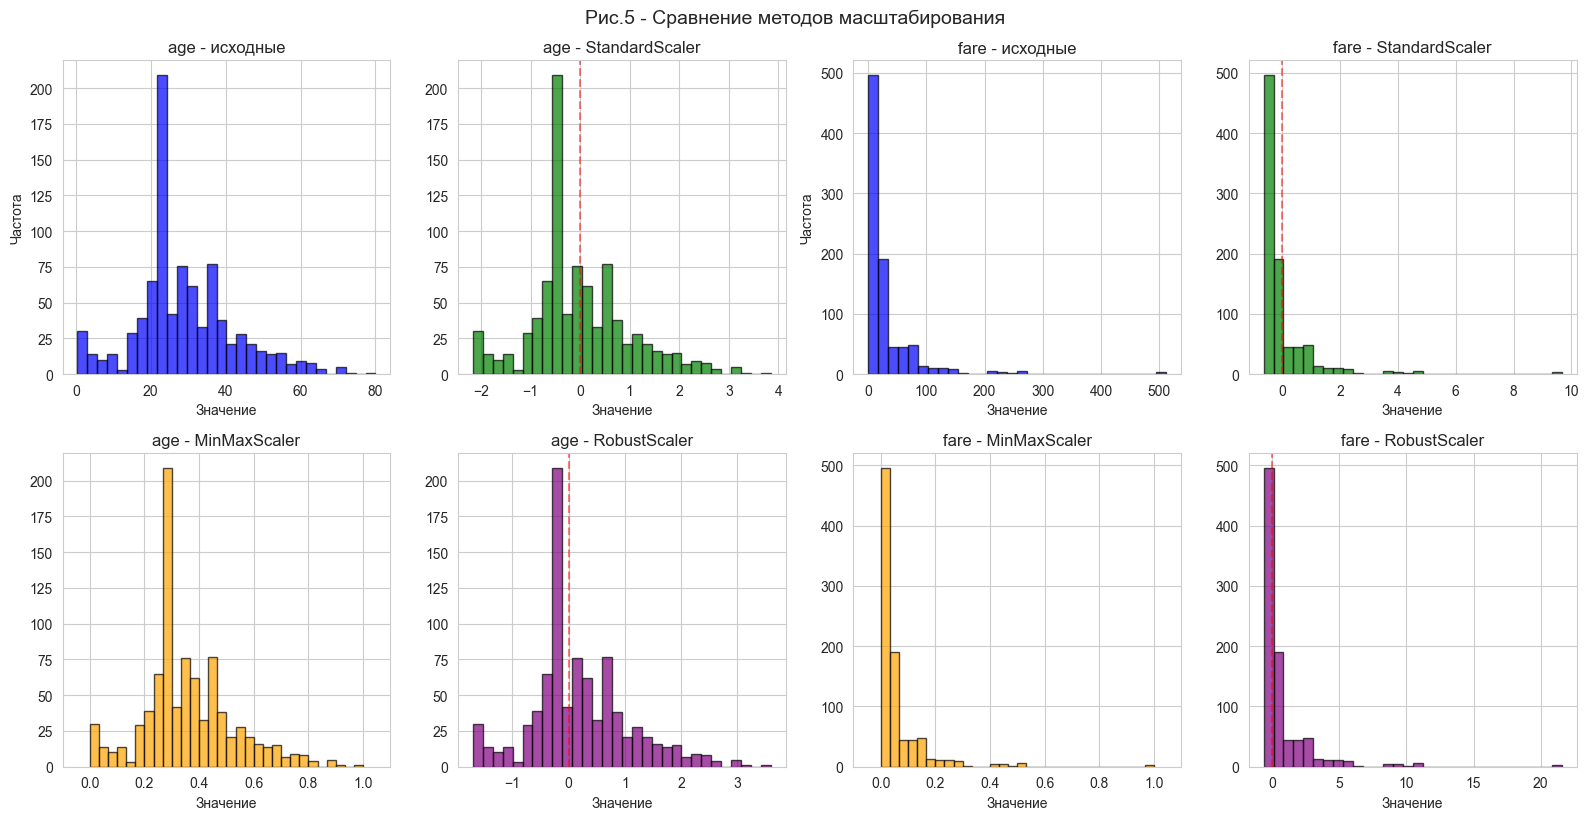

In [11]:

# 9. Сам масштаб


from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler

df_scaled = df_encoded.copy()

print("="*60)
print("9.1 Выбор метода масштабирования")
print("="*60)


cols_to_scale = ['age', 'fare']  # явно указываем, что масштабируем

print(f"Признаки для масштабирования: {cols_to_scale}")

print("""
Доступные методы масштабирования:

1. StandardScaler - центрирует (среднее=0) и нормирует (дисперсия=1)
   Лучше для: данных с нормальным распределением
   
2. MinMaxScaler - приводит к диапазону [0, 1]
   Лучше для: нейросетей, когда нужны строгие границы
   
3. RobustScaler - использует медиану и квартили, устойчив к выбросам
   Лучше для: данных с большим количеством выбросов
""")


print("\nАнализ выбросов для выбора метода:")

for col in cols_to_scale:
    Q1 = df_scaled[col].quantile(0.25)
    Q3 = df_scaled[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = df_scaled[(df_scaled[col] < lower_bound) | (df_scaled[col] > upper_bound)]
    
    print(f"\n{col}:")
    print(f"  Q1 = {Q1:.2f}, Q3 = {Q3:.2f}, IQR = {IQR:.2f}")
    print(f"  Границы нормы: [{lower_bound:.2f}, {upper_bound:.2f}]")
    print(f"  Количество выбросов: {len(outliers)} ({len(outliers)/len(df_scaled)*100:.1f}%)")
    
    if len(outliers) > 0:
        print(f"  ! Есть выбросы - рекомендуется RobustScaler")

print("\n" + "="*60)
print("9.2 Применение разных")
print("="*60)


df_standard = df_scaled.copy()
df_minmax = df_scaled.copy()
df_robust = df_scaled.copy()

# 1. StandardScaler
standard_scaler = StandardScaler()
df_standard[cols_to_scale] = standard_scaler.fit_transform(df_standard[cols_to_scale])

# 2. MinMaxScaler
minmax_scaler = MinMaxScaler()
df_minmax[cols_to_scale] = minmax_scaler.fit_transform(df_minmax[cols_to_scale])

# 3. RobustScaler
robust_scaler = RobustScaler()
df_robust[cols_to_scale] = robust_scaler.fit_transform(df_robust[cols_to_scale])


print("\nСравнение статистик после масштабирования:")

for col in cols_to_scale:
    print(f"\n{col}:")
    print(f"  Исходные данные: среднее={df_scaled[col].mean():.2f}, std={df_scaled[col].std():.2f}")
    print(f"  StandardScaler:  среднее={df_standard[col].mean():.2f}, std={df_standard[col].std():.2f}")
    print(f"  MinMaxScaler:    среднее={df_minmax[col].mean():.2f}, std={df_minmax[col].std():.2f}, мин={df_minmax[col].min():.2f}, макс={df_minmax[col].max():.2f}")
    print(f"  RobustScaler:    среднее={df_robust[col].mean():.2f}, std={df_robust[col].std():.2f}")

print("\n" + "="*60)
print("9.3 Визуализация разныхВ")
print("="*60)


fig, axes = plt.subplots(2, 4, figsize=(16, 8))

# Исходные данные
for i, col in enumerate(cols_to_scale):
    axes[0, i*2].hist(df_scaled[col], bins=30, edgecolor='black', alpha=0.7, color='blue')
    axes[0, i*2].set_title(f'{col} - исходные')
    axes[0, i*2].set_xlabel('Значение')
    axes[0, i*2].set_ylabel('Частота')

# StandardScaler
for i, col in enumerate(cols_to_scale):
    axes[0, i*2+1].hist(df_standard[col], bins=30, edgecolor='black', alpha=0.7, color='green')
    axes[0, i*2+1].set_title(f'{col} - StandardScaler')
    axes[0, i*2+1].set_xlabel('Значение')
    axes[0, i*2+1].axvline(0, color='red', linestyle='--', alpha=0.5)

# MinMaxScaler
for i, col in enumerate(cols_to_scale):
    axes[1, i*2].hist(df_minmax[col], bins=30, edgecolor='black', alpha=0.7, color='orange')
    axes[1, i*2].set_title(f'{col} - MinMaxScaler')
    axes[1, i*2].set_xlabel('Значение')
    axes[1, i*2].set_xlim([-0.1, 1.1])

# RobustScaler
for i, col in enumerate(cols_to_scale):
    axes[1, i*2+1].hist(df_robust[col], bins=30, edgecolor='black', alpha=0.7, color='purple')
    axes[1, i*2+1].set_title(f'{col} - RobustScaler')
    axes[1, i*2+1].set_xlabel('Значение')
    axes[1, i*2+1].axvline(0, color='red', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.suptitle('Рис.5 - Сравнение методов масштабирования', y=1.02, fontsize=14)
plt.show()

10.1 Оптимальный метод

Критерии выбора метода:
1. Наличие выбросов → RobustScaler (устойчив к выбросам)
2. Нормальное распределение → StandardScaler
3. Необходимость в строгих границах → MinMaxScaler
4. Дальнейшее использование в моделях:
   - Для линейных моделей и SVM лучше StandardScaler
   - Для нейросетей часто используют MinMaxScaler
   - Для деревьев решений масштабирование не нужно


Анализ выбросов:
age: 26 выбросов (2.9%)
fare: 116 выбросов (13.0%)

В данных есть выбросы. Выбираем RobustScaler

Итоговый выбор: RobustScaler

10.2 Статистика после масштабирования
       mean    std    min     max
age   0.204  0.883 -1.705   3.600
fare  0.769  2.152 -0.626  21.563

10.3 До и после
  Признак   Этап  Среднее  Стд_отклонение  Минимум  Максимум
0     age     До   29.066          13.245    0.420    80.000
1    fare     До   32.204          49.693    0.000   512.329
2     age  После    0.204           0.883   -1.705     3.600
3    fare  После    0.769           2.152   -0.626    21.5

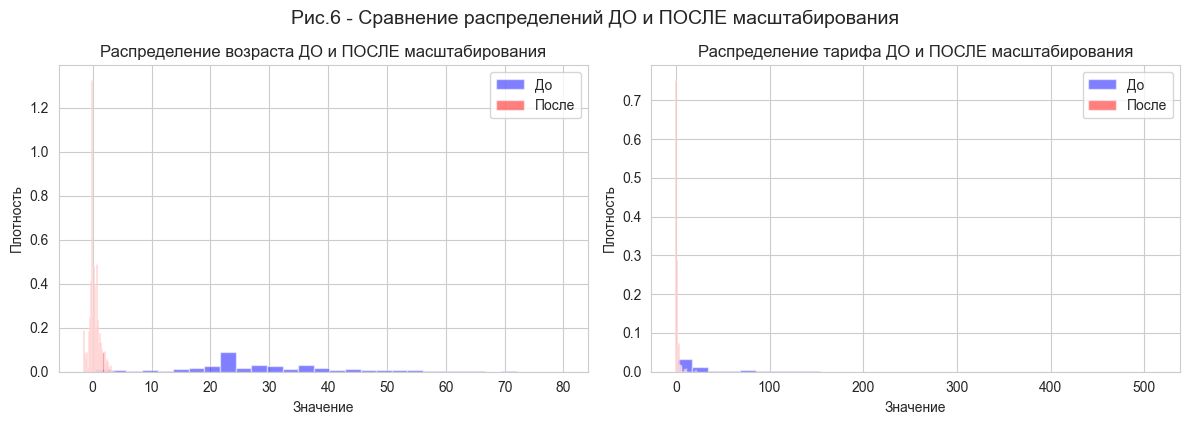

In [12]:
# 10. выбор оптимального
print("="*60)
print("10.1 Оптимальный метод")
print("="*60)

print("""
Критерии выбора метода:
1. Наличие выбросов → RobustScaler (устойчив к выбросам)
2. Нормальное распределение → StandardScaler
3. Необходимость в строгих границах → MinMaxScaler
4. Дальнейшее использование в моделях:
   - Для линейных моделей и SVM лучше StandardScaler
   - Для нейросетей часто используют MinMaxScaler
   - Для деревьев решений масштабирование не нужно
""")


print("\nАнализ выбросов:")

has_outliers = False
for col in cols_to_scale:
    Q1 = df_scaled[col].quantile(0.25)
    Q3 = df_scaled[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = df_scaled[(df_scaled[col] < lower_bound) | (df_scaled[col] > upper_bound)]
    
    print(f"{col}: {len(outliers)} выбросов ({len(outliers)/len(df_scaled)*100:.1f}%)")
    if len(outliers) > 0:
        has_outliers = True

if has_outliers:
    print("\nВ данных есть выбросы. Выбираем RobustScaler")
    selected_scaler = RobustScaler()
    selected_method = "RobustScaler"
    df_final = df_robust.copy()
else:
    print("\nВыбросов нет. Можно использовать StandardScaler")
    selected_scaler = StandardScaler()
    selected_method = "StandardScaler"
    df_final = df_standard.copy()

print(f"\nИтоговый выбор: {selected_method}")

print("\n" + "="*60)
print("10.2 Статистика после масштабирования")
print("="*60)


stats_after = df_final[cols_to_scale].describe().T[['mean', 'std', 'min', 'max']]
print(stats_after.round(3))


print("\n" + "="*60)
print("10.3 До и после")
print("="*60)

comparison = pd.DataFrame({
    'Признак': cols_to_scale * 2,
    'Этап': ['До'] * len(cols_to_scale) + ['После'] * len(cols_to_scale),
    'Среднее': list(df_scaled[cols_to_scale].mean().values) + list(df_final[cols_to_scale].mean().values),
    'Стд_отклонение': list(df_scaled[cols_to_scale].std().values) + list(df_final[cols_to_scale].std().values),
    'Минимум': list(df_scaled[cols_to_scale].min().values) + list(df_final[cols_to_scale].min().values),
    'Максимум': list(df_scaled[cols_to_scale].max().values) + list(df_final[cols_to_scale].max().values)
})
print(comparison.round(3))


fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# График 1: Age
axes[0].hist(df_scaled['age'], bins=30, alpha=0.5, label='До', color='blue', density=True)
axes[0].hist(df_final['age'], bins=30, alpha=0.5, label='После', color='red', density=True)
axes[0].set_title('Распределение возраста ДО и ПОСЛЕ масштабирования')
axes[0].set_xlabel('Значение')
axes[0].set_ylabel('Плотность')
axes[0].legend()


axes[1].hist(df_scaled['fare'], bins=30, alpha=0.5, label='До', color='blue', density=True)
axes[1].hist(df_final['fare'], bins=30, alpha=0.5, label='После', color='red', density=True)
axes[1].set_title('Распределение тарифа ДО и ПОСЛЕ масштабирования')
axes[1].set_xlabel('Значение')
axes[1].set_ylabel('Плотность')
axes[1].legend()

plt.tight_layout()
plt.suptitle('Рис.6 - Сравнение распределений ДО и ПОСЛЕ масштабирования', y=1.05, fontsize=14)
plt.show()

In [13]:
# 11. Итоговый датасет

print("="*60)
print("11.1 Итоги")
print("="*60)

print(f"Исходный датасет: {df.shape}")
print(f"После обработки пропусков: {df_clean.shape}")
print(f"После кодирования: {df_encoded.shape}")
print(f"После масштабирования: {df_final.shape}")

print("\nИтог:")
print(f"• Строк (пассажиров): {df_final.shape[0]}")
print(f"• Столбцов (признаков): {df_final.shape[1]}")
print(f"• Из них исходных признаков: {df.shape[1]}")
print(f"• Добавлено при кодировании: {df_final.shape[1] - df.shape[1] + 3} (+3 за удаленные deck, embark_town)")

print("\nТиппы признаков:")
print(df_final.dtypes.value_counts())

print("\n" + "="*60)
print("11.2 первые 5 строк")
print("="*60)
df_final.head()

11.1 Итоги
Исходный датасет: (891, 15)
После обработки пропусков: (891, 13)
После кодирования: (891, 26)
После масштабирования: (891, 26)

Итог:
• Строк (пассажиров): 891
• Столбцов (признаков): 26
• Из них исходных признаков: 15
• Добавлено при кодировании: 14 (+3 за удаленные deck, embark_town)

Типпы признаков:
bool        11
int64        8
object       4
float64      2
category     1
Name: count, dtype: int64

11.2 первые 5 строк


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,alive,alone,sex_encoded,alone_encoded,adult_male_encoded,who_encoded,embarked_C,embarked_Q,embarked_S,who_child,who_man,who_woman,class_1,class_2,class_3
0,0,3,male,-0.266667,1,0,-0.312011,S,Third,man,True,no,False,1,0,1,1,False,False,True,False,True,False,False,False,True
1,1,1,female,0.800000,1,0,2.461242,C,First,woman,False,yes,False,0,0,0,2,True,False,False,False,False,True,True,False,False
2,1,3,female,0.000000,0,0,-0.282777,S,Third,woman,False,yes,True,0,1,0,2,False,False,True,False,False,True,False,False,True
3,1,1,female,0.600000,1,0,1.673732,S,First,woman,False,yes,False,0,0,0,2,False,False,True,False,False,True,True,False,False
4,0,3,male,0.600000,0,0,-0.277363,S,Third,man,True,no,True,1,1,1,1,False,False,True,False,True,False,False,False,True
